# Processing Model 8F for the Toronto Political Clusters Data Story

This notebook takes the **finalized Model 8F** clustering (50/50 blend of citywide-relative
and within-riding-relative electoral features, PCA + k-means, k=5 — chosen and interpreted in
`explore_neighbourhood_clusters.ipynb` and `explore_clusters_makeup.ipynb`) and produces the
**final, clean data outputs** a Svelte frontend will load directly.

**This notebook does not re-run model selection.** It reproduces Model 8F exactly (verified
against the saved reference profile below), attaches the demographic and geographic context
already validated in the makeup notebook, and writes it out as frontend-ready JSON/GeoJSON.

**Outputs:**
- `data/clustering_neighbourhoods/processed_clusters/` — full-resolution debug/QA outputs
  (CSV, GeoPackage, uncompressed GeoJSON, full-property JSON)
- `src/data/clustering_neighbourhoods/` — the three frontend files: `clusters_summary.json`,
  `ct_clusters.geojson`, `ct_values.json`, plus `clusters_metadata.json`

**Only this notebook is written to.** `explore_neighbourhood_clusters.ipynb` and
`explore_clusters_makeup.ipynb` are used only as reference for how Model 8F is built and
interpreted, and are never modified.

In [1]:
import json
import math
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import box as shapely_box
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

/home/aniket/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT = Path("../..")

# Tract-level election results (source for the 8F feature matrix)
MAP_DIR    = ROOT / "data/toronto_election_turnout/interpolation/map"
RIDING_DIR = ROOT / "data/toronto_election_turnout/elections/raw"

# Reference notebook's saved output, used only for QA (never as our only source of truth)
CLUSTER_ROOT        = ROOT / "data/clustering_neighbourhoods"
EXPLORE_DIR         = CLUSTER_ROOT / "explore"
REF_8F_PROFILES_CSV = EXPLORE_DIR / "8f_blend50_profiles.csv"

# Census — tract-level (CT) file, joined 1:1 to our 585 clustered tracts (see §4)
CENSUS_CT_CSV = CLUSTER_ROOT / "census/toronto-ct-small.csv"

# ── Output locations ─────────────────────────────────────────────────────────
PROCESSED_DIR = CLUSTER_ROOT / "processed_clusters"          # rich debug/QA outputs
FRONTEND_DIR  = ROOT / "src/data/clustering_neighbourhoods"  # Svelte-facing outputs
for d in [PROCESSED_DIR, FRONTEND_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Model 8F definition (must match the reference notebooks exactly) ─────────
K_CHOSEN          = 5
ALPHA_CITY        = 0.5    # blend weight on the city-relative block (8F = 50/50)
RANDOM_STATE      = 42
PCA_VAR_THRESHOLD = 0.90

# ── Election feature vocabulary (identical to the reference notebooks) ───────
MUN_CANDIDATE_KEYS = {
    "chow":     "Chow Olivia",
    "bailao":   "Bailão Ana",
    "saunders": "Saunders Mark",
    "furey":    "Furey Anthony",
    "matlow":   "Matlow Josh",
}
PROV_PARTY_KEYS = {
    "pc":      "progressive_conservative_party_of_ontario",
    "ndp":     "new_democratic_party_of_ontario",
    "liberal": "ontario_liberal_party",
    "green":   "green_party_of_ontario",
}
FED_PARTY_KEYS = {
    "liberal":      "liberal",
    "conservative": "conservative",
    "ndp":          "ndp_new_democratic_party",
    "green":        "green_party",
}

ALL_COLS = [
    "mun_turnout",
    "mun_chow", "mun_bailao", "mun_saunders", "mun_furey", "mun_matlow", "mun_other",
    "prov_turnout",
    "prov_pc", "prov_ndp", "prov_liberal", "prov_green", "prov_other",
    "fed_turnout",
    "fed_liberal", "fed_conservative", "fed_ndp", "fed_green", "fed_other",
]
TURNOUT_COLS    = ["mun_turnout", "prov_turnout", "fed_turnout"]
MUN_SHARE_COLS  = ["mun_chow", "mun_bailao", "mun_saunders", "mun_furey", "mun_matlow", "mun_other"]
PROV_SHARE_COLS = ["prov_pc", "prov_ndp", "prov_liberal", "prov_green", "prov_other"]
FED_SHARE_COLS  = ["fed_liberal", "fed_conservative", "fed_ndp", "fed_green", "fed_other"]
SHARE_COLS      = MUN_SHARE_COLS + PROV_SHARE_COLS + FED_SHARE_COLS

ELECTION_BLOCKS = {
    "municipal":  ["mun_turnout"]  + MUN_SHARE_COLS,
    "provincial": ["prov_turnout"] + PROV_SHARE_COLS,
    "federal":    ["fed_turnout"]  + FED_SHARE_COLS,
}

# ── Final public-facing labels, in progressive -> conservative display order ─
# Mapped to actual cluster IDs later (§2) — never assumed positionally beforehand.
FINAL_LABELS_BY_ORDER = [
    "Progressive Core",
    "Mobile Middle",
    "Civic Professionals",
    "Working Suburbanites",
    "Settled Conservatives",
]

# ── Presentation palette: 5-stop yellow/orange -> red/magenta -> purple/blue ──
# Solid hex, no alpha, chosen for readability as map fills, legend swatches, and chart bars.
# Assigned to *display order* (index 0 = most progressive), not to raw cluster ID.
ORDER_PALETTE = [
    "#F5D76E",   # most progressive
    "#F2A233",
    "#E4362A",
    "#3E6FA8",
    "#472366",   # most conservative
]

# ── Census characteristics to extract from the tract-level (CT) file ─────────
# (output name, characteristic_id, kind, numerator_code, denominator_code)
# IDs verified directly against the CT file in §4, not assumed from any other source.
CENSUS_VARS = [
    ("pop_2021",                     1, "count",             "pop_2021",                   None),
    ("pop_density_statcan",          6, "density_statcan",   "pop_density",                None),
    ("age_65_over_pct",             37, "pct_only",          "age_65_over",                "pop_2021"),
    ("age_mean",                    39, "avg_pop_weighted",  "age_mean",                   "pop_2021"),
    ("pvt_house_total",             50, "count",             "pvt_house_total",            None),
    ("pvt_house_avg_size",          57, "avg_hh_weighted",   "pvt_house_avg_size",         "pvt_house_total"),
    ("income_total_median",        113, "median_approx",     "income_total_median",        "pop_2021"),
    ("housing_tenure_total",      1414, "count",             "housing_tenure_total",       None),
    ("housing_tenure_renter",     1416, "count",             "housing_tenure_renter",      "housing_tenure_total"),
    ("housing_shelter_total",     1465, "count",             "housing_shelter_total",      None),
    ("housing_shelter_30plus",    1467, "count",             "housing_shelter_30plus",     "housing_shelter_total"),
    ("citizen_total",             1522, "count",             "citizen_total",              None),
    ("citizen_canadian",          1523, "count",             "citizen_canadian",           "citizen_total"),
    ("visible_minority_total",    1683, "count",             "visible_minority_total",     None),
    ("visible_minority_yes",      1684, "count",             "visible_minority_yes",       "visible_minority_total"),
    ("mobility_total",            1983, "count",             "mobility_total",             None),
    ("mobility_migrants",         1987, "count",             "mobility_migrants",          "mobility_total"),
    ("education_total",           1998, "count",             "education_total",            None),
    ("education_bachelor_higher", 2008, "count",             "education_bachelor_higher",  "education_total"),
    ("commute_mode_total",        2603, "count",             "commute_mode_total",         None),
    ("commute_mode_car_truck_van",2604, "count",             "commute_mode_car_truck_van", "commute_mode_total"),
    ("commute_mode_transit",      2607, "count",             "commute_mode_transit",       "commute_mode_total"),
    ("commute_duration_total",    2611, "count",             "commute_duration_total",     None),
    ("commute_duration_60plus",   2616, "count",             "commute_duration_60plus",    "commute_duration_total"),
]
CENSUS_CHAR_IDS = [v[1] for v in CENSUS_VARS]

# Simplification tolerance for the web GeoJSON, in degrees (~9 m at Toronto's latitude) —
# light enough to preserve tract shape while cutting vertex count for the frontend map.
GEOM_SIMPLIFY_TOLERANCE = 0.0001

# ── Human-readable display labels & units, reused for descriptions and metadata ──
VAR_DISPLAY_LABELS = {
    "mun_turnout": "2023 mayoral turnout", "mun_chow": "Chow (2023 mayoral)",
    "mun_bailao": "Bailão (2023 mayoral)", "mun_saunders": "Saunders (2023 mayoral)",
    "mun_furey": "Furey (2023 mayoral)", "mun_matlow": "Matlow (2023 mayoral)",
    "mun_other": "Other mayoral candidates",
    "prov_turnout": "2025 provincial turnout", "prov_pc": "Ontario PC (2025 provincial)",
    "prov_ndp": "Ontario NDP (2025 provincial)", "prov_liberal": "Ontario Liberal (2025 provincial)",
    "prov_green": "Ontario Green (2025 provincial)", "prov_other": "Other provincial parties",
    "fed_turnout": "2025 federal turnout", "fed_liberal": "Liberal (2025 federal)",
    "fed_conservative": "Conservative (2025 federal)", "fed_ndp": "NDP (2025 federal)",
    "fed_green": "Green (2025 federal)", "fed_other": "Other federal parties",
    "population": "Total population", "population_density": "Population density (per km²)",
    "pct_age_65_over": "Age 65+", "avg_age": "Average age",
    "avg_household_size": "Average household size", "income_median_approx": "Approx. median income",
    "pct_renter": "Renter households", "pct_shelter_burdened_30plus": "Spending 30%+ on shelter",
    "pct_canadian_citizen": "Canadian citizens", "pct_visible_minority": "Visible minority / racialized population",
    "pct_migrant_5yr": "Migrants in the last 5 years", "pct_bachelor_or_higher": "Bachelor's degree or higher",
    "pct_commute_car": "Commute by car/truck/van", "pct_commute_transit": "Commute by public transit",
    "pct_commute_60plus_min": "Commute 60+ minutes",
}
VAR_UNITS = {
    "population": "people", "population_density": "people / km²", "avg_age": "years",
    "avg_household_size": "people", "income_median_approx": "CAD $",
}
# Everything else not listed above is a percentage (0-100) or a percentage-point deviation.

print(f"Model 8F config: k={K_CHOSEN}, alpha_city={ALPHA_CITY}, random_state={RANDOM_STATE}")
print(f"Frontend output dir:  {FRONTEND_DIR.resolve()}")
print(f"Processed output dir: {PROCESSED_DIR.resolve()}")

Model 8F config: k=5, alpha_city=0.5, random_state=42
Frontend output dir:  /home/aniket/Programming/place-and-politics-toronto/src/data/clustering_neighbourhoods
Processed output dir: /home/aniket/Programming/place-and-politics-toronto/data/clustering_neighbourhoods/processed_clusters


## 1. Reproducing Model 8F

We rebuild the 8F pipeline in the same five steps used in `explore_clusters_makeup.ipynb`,
which was itself verified bit-for-bit against `explore_neighbourhood_clusters.ipynb`'s saved
output. Because every step uses the same input files, the same `RANDOM_STATE`, and the same
code, the resulting cluster assignment should again be identical to the published reference —
we verify this explicitly below rather than assuming it.

1. Extract raw vote shares + turnout per tract for all three elections.
2. Compute citywide (vote-weighted) benchmarks and city-relative deviations.
3. Assign each tract to its municipal ward, provincial riding, and federal riding.
4. Compute vote-weighted within-riding residuals.
5. Blend city-relative and riding-relative signals 50/50, run PCA → k-means (k=5).

In [3]:
# ── Step 1: extract raw vote shares + turnout per tract ──────────────────────────
def _parse_json(val):
    if isinstance(val, dict): return val
    if isinstance(val, str):  return json.loads(val) if val else {}
    return {}

def load_gdf(filename):
    gdf = gpd.read_file(MAP_DIR / filename)
    for col in ["party_votes", "candidate_votes", "top_candidates"]:
        if col in gdf.columns:
            gdf[col] = gdf[col].apply(_parse_json)
    return gdf

mun_gdf  = load_gdf("municipal_2023_mayor_ct_map.geojson")
prov_gdf = load_gdf("provincial_2025_ct_map.geojson")
fed_gdf  = load_gdf("federal_2025_ct_map.geojson")

def _safe_share(votes, total):
    return votes / total if total > 0 else 0.0

def extract_mun_features(row):
    cvotes, total = row["candidate_votes"], row["estimated_valid_candidate_votes"]
    s = {f"mun_{k}": _safe_share(cvotes.get(v, 0.0), total) for k, v in MUN_CANDIDATE_KEYS.items()}
    s["mun_other"] = max(0.0, 1.0 - sum(s.values())); s["mun_turnout"] = row["estimated_turnout"]
    return s

def extract_prov_features(row):
    pvotes, total = row["party_votes"], row["estimated_valid_candidate_votes"]
    s = {f"prov_{k}": _safe_share(pvotes.get(v, 0.0), total) for k, v in PROV_PARTY_KEYS.items()}
    s["prov_other"] = max(0.0, 1.0 - sum(s.values())); s["prov_turnout"] = row["estimated_turnout"]
    return s

def extract_fed_features(row):
    pvotes, total = row["party_votes"], row["estimated_valid_candidate_votes"]
    s = {f"fed_{k}": _safe_share(pvotes.get(v, 0.0), total) for k, v in FED_PARTY_KEYS.items()}
    s["fed_other"] = max(0.0, 1.0 - sum(s.values())); s["fed_turnout"] = row["estimated_turnout"]
    return s

with tqdm(total=3, desc="Extracting election features") as pbar:
    mun_feats  = pd.DataFrame([extract_mun_features(r)  for _, r in mun_gdf.iterrows()],  index=mun_gdf["ct_id"]); pbar.update()
    prov_feats = pd.DataFrame([extract_prov_features(r) for _, r in prov_gdf.iterrows()], index=prov_gdf["ct_id"]); pbar.update()
    fed_feats  = pd.DataFrame([extract_fed_features(r)  for _, r in fed_gdf.iterrows()],  index=fed_gdf["ct_id"]); pbar.update()

raw_df = mun_feats.join(prov_feats, how="inner").join(fed_feats, how="inner")[ALL_COLS]
raw_df = raw_df.fillna(raw_df.mean())

geom_df = mun_gdf.set_index("ct_id")[["geometry"]]
raw_gdf = gpd.GeoDataFrame(raw_df.join(geom_df, how="inner").reset_index(), geometry="geometry", crs=mun_gdf.crs)

# Anomaly flag: tracts where interpolation could not recover any named-party result in >=1
# election (100% falls into "other"). Excluded from k-means fitting, assigned post-hoc.
_anom = (raw_gdf["mun_other"] >= 0.99) | (raw_gdf["prov_other"] >= 0.99) | (raw_gdf["fed_other"] >= 0.99)
anomaly_mask = _anom.values

# If the input files ever change shape, fail loudly rather than silently clustering fewer/more tracts.
assert len(raw_gdf) == 585, f"Expected 585 census tracts, got {len(raw_gdf)} — check input files."
assert raw_gdf["ct_id"].duplicated().sum() == 0, "Duplicate ct_id in the election feature table."

# A separate, milder data-quality note (not an anomaly-mask case): `estimated_turnout` is
# itself an areal interpolation of two independently-estimated counts (votes and electors). For
# one very small-population tract this yields turnout slightly over 100% (see §11 QA and
# `metadata["notes"]`) — kept as-is rather than clamped, since silently altering an estimate
# would misrepresent the underlying interpolation's actual uncertainty.
n_turnout_over_100 = int((raw_gdf[TURNOUT_COLS] > 1.0).any(axis=1).sum())
if n_turnout_over_100:
    print(f"Note: {n_turnout_over_100} tract(s) have an interpolated turnout estimate over 100% "
          f"(small-population interpolation noise) — kept as published, not clamped.")

print(f"Tracts loaded: {len(raw_gdf)}  |  CRS: {raw_gdf.crs}  |  Anomalous tracts excluded from fitting: {anomaly_mask.sum()}")

Extracting election features:   0%|          | 0/3 [00:00<?, ?it/s]

Note: 1 tract(s) have an interpolated turnout estimate over 100% (small-population interpolation noise) — kept as published, not clamped.
Tracts loaded: 585  |  CRS: EPSG:4326  |  Anomalous tracts excluded from fitting: 2


In [4]:
# ── Step 2: citywide (vote-weighted) benchmarks and city-relative deviations ──────
citywide = {}

mun_valid = mun_gdf["estimated_valid_candidate_votes"]
for k, v in MUN_CANDIDATE_KEYS.items():
    citywide[f"mun_{k}"] = mun_gdf["candidate_votes"].apply(lambda d, v=v: d.get(v, 0.0)).sum() / mun_valid.sum()
citywide["mun_other"]   = max(0.0, 1.0 - sum(citywide[f"mun_{k}"] for k in MUN_CANDIDATE_KEYS))
citywide["mun_turnout"] = (mun_gdf["estimated_turnout"] * mun_gdf["estimated_electors"]).sum() / mun_gdf["estimated_electors"].sum()

prov_valid = prov_gdf["estimated_valid_candidate_votes"]
for k, v in PROV_PARTY_KEYS.items():
    citywide[f"prov_{k}"] = prov_gdf["party_votes"].apply(lambda d, v=v: d.get(v, 0.0)).sum() / prov_valid.sum()
citywide["prov_other"]   = max(0.0, 1.0 - sum(citywide[f"prov_{k}"] for k in PROV_PARTY_KEYS))
citywide["prov_turnout"] = (prov_gdf["estimated_turnout"] * prov_gdf["estimated_electors"]).sum() / prov_gdf["estimated_electors"].sum()

fed_valid = fed_gdf["estimated_valid_candidate_votes"]
for k, v in FED_PARTY_KEYS.items():
    citywide[f"fed_{k}"] = fed_gdf["party_votes"].apply(lambda d, v=v: d.get(v, 0.0)).sum() / fed_valid.sum()
citywide["fed_other"]   = max(0.0, 1.0 - sum(citywide[f"fed_{k}"] for k in FED_PARTY_KEYS))
citywide["fed_turnout"] = (fed_gdf["estimated_turnout"] * fed_gdf["estimated_electors"]).sum() / fed_gdf["estimated_electors"].sum()

citywide_s = pd.Series(citywide)[ALL_COLS]
rel_df = raw_df.subtract(citywide_s)   # tract minus citywide, in vote-share units (x100 = pp)

print("Citywide benchmarks (%):")
print((citywide_s[TURNOUT_COLS + SHARE_COLS] * 100).round(1).to_string())

Citywide benchmarks (%):
mun_turnout         37.2
prov_turnout        42.6
fed_turnout         65.0
mun_chow            37.2
mun_bailao          32.5
mun_saunders         8.6
mun_furey            5.0
mun_matlow           4.9
mun_other           11.9
prov_pc             34.0
prov_ndp            23.3
prov_liberal        38.4
prov_green           2.7
prov_other           1.7
fed_liberal         58.4
fed_conservative    33.8
fed_ndp              6.4
fed_green            0.7
fed_other            0.7


In [5]:
# ── Step 3: assign each tract to its municipal ward / provincial riding / federal riding ──
subdiv_gdf = gpd.read_file(RIDING_DIR / "toronto_2023_subdivisions.geojson")
subdiv_gdf["ward"] = subdiv_gdf["AREA_LONG_CODE"].str[:2].astype(str)
ward_gdf = subdiv_gdf.dissolve(by="ward")

prov_ridings = gpd.read_file(RIDING_DIR / "ont_2025_ridings.geojson")
fed_ridings  = gpd.read_file(RIDING_DIR / "fed_2025_ridings.geojson")

def assign_ridings(ct_gdf, ward_gdf, prov_ridings, fed_ridings):
    centroids_gdf = gpd.GeoDataFrame({"ct_id": ct_gdf["ct_id"].values},
                                      geometry=ct_gdf.geometry.centroid.values, crs=ct_gdf.crs)
    bbox = shapely_box(*ct_gdf.total_bounds)
    prov_local = prov_ridings[prov_ridings.geometry.intersects(bbox)][["RIDINGNAME", "geometry"]].reset_index(drop=True)
    fed_local  = fed_ridings[fed_ridings.geometry.intersects(bbox)][["RIDINGNAME", "geometry"]].reset_index(drop=True)
    ward_local = ward_gdf.reset_index()[["ward", "geometry"]].copy()

    def sjoin_with_fallback(pts, polys, id_col, out_col):
        joined = gpd.sjoin(pts, polys[[id_col, "geometry"]], how="left", predicate="within")
        joined = joined.drop_duplicates("ct_id")[["ct_id", id_col]]
        missing = joined[id_col].isna()
        if missing.any():
            for _, row in joined[missing].iterrows():
                pt = pts.loc[pts["ct_id"] == row["ct_id"], "geometry"].values[0]
                nearest = polys.geometry.distance(pt).idxmin()
                joined.loc[joined["ct_id"] == row["ct_id"], id_col] = polys.loc[nearest, id_col]
        return joined.rename(columns={id_col: out_col})

    ward_j = sjoin_with_fallback(centroids_gdf, ward_local, "ward",       "mun_riding")
    prov_j = sjoin_with_fallback(centroids_gdf, prov_local, "RIDINGNAME", "prov_riding")
    fed_j  = sjoin_with_fallback(centroids_gdf, fed_local,  "RIDINGNAME", "fed_riding")
    return ward_j.merge(prov_j, on="ct_id").merge(fed_j, on="ct_id")

riding_df = assign_ridings(raw_gdf, ward_gdf, prov_ridings, fed_ridings)
riding_df["ward_label"] = "Ward " + riding_df["mun_riding"].astype(int).astype(str)

assert riding_df["mun_riding"].notna().all() and riding_df["prov_riding"].notna().all() and riding_df["fed_riding"].notna().all(), \
    "Some tracts are missing a riding assignment — stop and investigate."
print(f"Tracts assigned to a riding: {len(riding_df)}")
print(f"  Wards: {riding_df['mun_riding'].nunique()}  |  Provincial ridings: {riding_df['prov_riding'].nunique()}  |  Federal ridings: {riding_df['fed_riding'].nunique()}")

Tracts assigned to a riding: 585
  Wards: 25  |  Provincial ridings: 25  |  Federal ridings: 24


In [6]:
# ── Step 4: vote-weighted within-riding residuals ─────────────────────────────────
MUN_COLS, PROV_COLS, FED_COLS = ["mun_turnout"] + MUN_SHARE_COLS, ["prov_turnout"] + PROV_SHARE_COLS, ["fed_turnout"] + FED_SHARE_COLS

def compute_vote_weighted_residuals(raw_gdf, riding_df, mun_gdf, prov_gdf, fed_gdf, mun_cols, prov_cols, fed_cols):
    all_cols = mun_cols + prov_cols + fed_cols
    df = raw_gdf[all_cols].copy(); df.index = raw_gdf["ct_id"]
    df = df.join(riding_df.set_index("ct_id"))
    df["mun_votes"], df["mun_elecs"]   = mun_gdf.set_index("ct_id")["estimated_valid_candidate_votes"], mun_gdf.set_index("ct_id")["estimated_electors"]
    df["prov_votes"], df["prov_elecs"] = prov_gdf.set_index("ct_id")["estimated_valid_candidate_votes"], prov_gdf.set_index("ct_id")["estimated_electors"]
    df["fed_votes"], df["fed_elecs"]   = fed_gdf.set_index("ct_id")["estimated_valid_candidate_votes"], fed_gdf.set_index("ct_id")["estimated_electors"]

    def wtd_mean(value_cols, weight_col, group_col):
        w = df[weight_col].fillna(1.0)
        out = {col: ((df[col] * w).groupby(df[group_col]).transform("sum") /
                     w.groupby(df[group_col]).transform("sum")).values for col in value_cols}
        return pd.DataFrame(out, index=df.index)

    splits = {"mun": (mun_cols, "mun_votes", "mun_elecs", "mun_riding"),
              "prov": (prov_cols, "prov_votes", "prov_elecs", "prov_riding"),
              "fed": (fed_cols, "fed_votes", "fed_elecs", "fed_riding")}
    parts = []
    for cols, votes_col, elecs_col, riding_col in splits.values():
        s_cols = [c for c in cols if "turnout" not in c]
        t_cols = [c for c in cols if "turnout" in c]
        parts += [wtd_mean(s_cols, votes_col, riding_col), wtd_mean(t_cols, elecs_col, riding_col)]
    riding_avg = pd.concat(parts, axis=1)[all_cols]
    res = pd.DataFrame(df[all_cols].values - riding_avg.values, columns=all_cols, index=df.index)
    return res, riding_avg

vw_resid_df, vw_riding_avg = compute_vote_weighted_residuals(
    raw_gdf, riding_df, mun_gdf, prov_gdf, fed_gdf, MUN_COLS, PROV_COLS, FED_COLS
)
print("Vote-weighted within-riding residuals computed for", len(vw_resid_df), "tracts.")

Vote-weighted within-riding residuals computed for 585 tracts.


In [7]:
# ── Step 5: block-weight, blend 50/50, PCA, k-means (k=5) — this IS Model 8F ──────
def apply_block_weights(X, col_names, blocks):
    X_out = X.copy().astype(float)
    for cols in blocks.values():
        idx = [col_names.index(c) for c in cols]
        X_out[:, idx] = StandardScaler().fit_transform(X_out[:, idx]) / np.sqrt(len(idx))
    return X_out

def apply_blend_weights(X_city, X_riding, col_names, blocks, alpha):
    X_c, X_r = np.zeros_like(X_city, dtype=float), np.zeros_like(X_riding, dtype=float)
    for cols in blocks.values():
        idx = [col_names.index(c) for c in cols]
        X_c[:, idx] = StandardScaler().fit_transform(X_city[:, idx])   / np.sqrt(len(idx))
        X_r[:, idx] = StandardScaler().fit_transform(X_riding[:, idx]) / np.sqrt(len(idx))
    return np.hstack([alpha * X_c, (1 - alpha) * X_r])

def assign_all(km, X_full, normal_idx, anomaly_mask):
    labels = np.empty(len(X_full), dtype=int)
    labels[normal_idx] = km.labels_
    for i in np.where(anomaly_mask)[0]:
        labels[i] = np.argmin(np.linalg.norm(km.cluster_centers_ - X_full[i], axis=1))
    return labels

X_city_vals   = rel_df[ALL_COLS].values.astype(float)
X_riding_vals = vw_resid_df[ALL_COLS].values.astype(float)
normal_idx    = np.where(~anomaly_mask)[0]

X_blend_8f = apply_blend_weights(X_city_vals, X_riding_vals, ALL_COLS, ELECTION_BLOCKS, ALPHA_CITY)

pca_probe = PCA(n_components=min(15, X_blend_8f.shape[1])).fit(X_blend_8f)
n_components_8f = int(np.searchsorted(np.cumsum(pca_probe.explained_variance_ratio_), PCA_VAR_THRESHOLD)) + 1
X_pca_8f = PCA(n_components=n_components_8f, random_state=RANDOM_STATE).fit_transform(X_blend_8f)

km_8f = KMeans(n_clusters=K_CHOSEN, n_init=30, random_state=RANDOM_STATE)
km_8f.fit(X_pca_8f[normal_idx])
labels_8f_raw = assign_all(km_8f, X_pca_8f, normal_idx, anomaly_mask)
silhouette_8f = silhouette_score(X_pca_8f[normal_idx], km_8f.labels_)

# Re-order cluster IDs by geographic centroid longitude (west -> east). This fixes the *raw*
# cluster ID used for joins/QA throughout; the progressive->conservative *display* order is
# layered on top of this in §2 and is a completely independent ordering.
centroid_x = np.array([raw_gdf.geometry.centroid.x.values[labels_8f_raw == c].mean() for c in range(K_CHOSEN)])
remap = {old: new for new, old in enumerate(np.argsort(centroid_x))}
labels_8f = np.array([remap[l] for l in labels_8f_raw])

raw_gdf["cluster_8f"] = labels_8f
cluster_sizes_8f = pd.Series(labels_8f).value_counts().sort_index()

print(f"Model 8F reproduced: {n_components_8f} PCA components (>= {PCA_VAR_THRESHOLD:.0%} variance), silhouette = {silhouette_8f:.4f}")
print("Cluster sizes (raw ID, west->east):", cluster_sizes_8f.to_dict())

Model 8F reproduced: 15 PCA components (>= 90% variance), silhouette = 0.1678
Cluster sizes (raw ID, west->east): {0: 140, 1: 92, 2: 62, 3: 197, 4: 94}


In [8]:
# ── QA: does this match the published 8F profile exactly? ────────────────────────
ref_profiles = pd.read_csv(REF_8F_PROFILES_CSV, index_col=0)

check_profiles = pd.DataFrame(
    np.array([rel_df[ALL_COLS].values[labels_8f == c].mean(axis=0) for c in range(K_CHOSEN)]) * 100,
    columns=ALL_COLS, index=[f"50-50 {c}" for c in range(K_CHOSEN)],
)
max_abs_diff = np.abs(check_profiles.values - ref_profiles[ALL_COLS].values).max()
sizes_match = (cluster_sizes_8f.values == ref_profiles["n_tracts"].values).all()

print(f"Reproduced n_tracts per cluster : {cluster_sizes_8f.tolist()}")
print(f"Published n_tracts per cluster  : {ref_profiles['n_tracts'].tolist()}")
print(f"Cluster sizes match exactly     : {sizes_match}")
print(f"Max abs. difference in profile pp values vs. published CSV: {max_abs_diff:.2e}")
assert sizes_match and max_abs_diff < 1e-6, "8F reproduction does not match the reference notebook — stop and investigate."
print("\n✅ Reproduction confirmed identical to the reference notebook's Model 8F.")

Reproduced n_tracts per cluster : [140, 92, 62, 197, 94]
Published n_tracts per cluster  : [140, 92, 62, 197, 94]
Cluster sizes match exactly     : True
Max abs. difference in profile pp values vs. published CSV: 1.78e-15

✅ Reproduction confirmed identical to the reference notebook's Model 8F.


## 2. Canonical Cluster Metadata

Cluster ID (0–4, fixed above by west→east centroid order) is a bookkeeping detail with no
political meaning. Every output instead orders the five groups on a **progressive ⟷
conservative lean score** — provincial NDP + municipal Chow share, minus provincial PC +
municipal Bailão share, all city-relative — and assigns the five final labels to that data-driven
order. We print the full raw-ID → display-order → label mapping below so the assignment is
verified, not assumed.

In [9]:
LEAN_SCORE = (check_profiles["prov_ndp"] + check_profiles["mun_chow"]
              - check_profiles["prov_pc"] - check_profiles["mun_bailao"])
LEAN_SCORE.index = range(K_CHOSEN)
DISPLAY_ORDER = LEAN_SCORE.sort_values(ascending=False).index.tolist()   # most progressive first

def slugify(label):
    return label.lower().replace(" ", "-")

CLUSTER_META = {
    c: {
        "cluster_id": c,
        "display_order": pos + 1,          # 1-indexed, matches the public-facing ordering
        "label": FINAL_LABELS_BY_ORDER[pos],
        "short_label": FINAL_LABELS_BY_ORDER[pos],
        "slug": slugify(FINAL_LABELS_BY_ORDER[pos]),
        "color": ORDER_PALETTE[pos],
        "lean_score": round(float(LEAN_SCORE[c]), 2),
    }
    for pos, c in enumerate(DISPLAY_ORDER)
}
CLUSTER_LABELS = {c: m["label"] for c, m in CLUSTER_META.items()}
PALETTE_BY_ID  = {c: m["color"] for c, m in CLUSTER_META.items()}

print("Raw cluster ID -> display order -> label -> lean score (verified, not assumed):")
meta_check = pd.DataFrame(CLUSTER_META).T.sort_values("display_order")
print(meta_check[["display_order", "label", "slug", "color", "lean_score"]].to_string(index=False))

Raw cluster ID -> display order -> label -> lean score (verified, not assumed):
display_order                 label                  slug   color lean_score
            1      Progressive Core      progressive-core #F5D76E      75.88
            2         Mobile Middle         mobile-middle #F2A233      33.41
            3   Civic Professionals   civic-professionals #E4362A     -12.95
            4  Working Suburbanites  working-suburbanites #3E6FA8      -17.0
            5 Settled Conservatives settled-conservatives #472366     -51.57


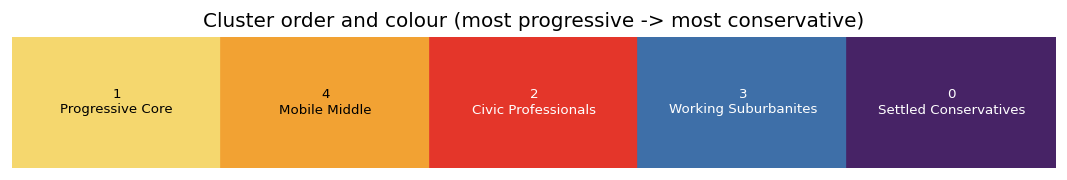

In [10]:
# ── Quick visual QA: palette swatches in the fixed display order ─────────────────
def _readable_text_color(hex_color):
    r, g, b = mcolors.to_rgb(hex_color)
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return "black" if luminance > 0.55 else "white"

fig, ax = plt.subplots(figsize=(9, 1.6))
for pos, c in enumerate(DISPLAY_ORDER):
    color = CLUSTER_META[c]["color"]
    ax.add_patch(mpatches.Rectangle((pos, 0), 1, 1, color=color))
    ax.text(pos + 0.5, 0.5, f"{c}\n{CLUSTER_META[c]['label']}", ha="center", va="center",
            fontsize=8, color=_readable_text_color(color))
ax.set_xlim(0, K_CHOSEN); ax.set_ylim(0, 1)
ax.set_title("Cluster order and colour (most progressive -> most conservative)")
ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Building the Master Tract Table

One row per census tract: ID, geometry, cluster assignment, riding assignments, raw vote
shares, city-relative deviations, within-riding deviations, and turnout. Demographic columns
are appended once the census join is built in §4.

In [11]:
tracts = raw_gdf[["ct_id", "geometry"] + ALL_COLS].copy()
tracts["cluster_id"]    = labels_8f
tracts["cluster_label"] = tracts["cluster_id"].map(CLUSTER_LABELS)
tracts["cluster_slug"]  = tracts["cluster_id"].map(lambda c: CLUSTER_META[c]["slug"])
tracts["cluster_color"] = tracts["cluster_id"].map(PALETTE_BY_ID)
tracts["display_order"] = tracts["cluster_id"].map(lambda c: CLUSTER_META[c]["display_order"])
tracts = tracts.merge(riding_df, on="ct_id", how="left")

rel_named = rel_df.add_suffix("_vs_city").reset_index()
vw_named  = vw_resid_df.add_suffix("_vs_riding").reset_index()
tracts = tracts.merge(rel_named, on="ct_id", how="left").merge(vw_named, on="ct_id", how="left")

# area_km2 from tract geometry (EPSG:3347, Statistics Canada Lambert) — used for density here
# and for cluster-level density in §5.
tracts["area_km2"] = tracts.to_crs(3347).geometry.area / 1e6

assert tracts["cluster_id"].notna().all(), "Every tract must have a cluster assignment."
assert tracts["geometry"].notna().all() and tracts.geometry.is_valid.all(), "Invalid/missing geometry found."
assert tracts["ct_id"].duplicated().sum() == 0, "Duplicate ct_id in the master tract table."
print(f"Master tract table: {tracts.shape[0]} tracts x {tracts.shape[1]} columns")
print(f"CRS: {tracts.crs}  |  geometry type(s): {tracts.geom_type.unique().tolist()}")
tracts.head(3)

Master tract table: 585 tracts x 69 columns
CRS: EPSG:4326  |  geometry type(s): ['MultiPolygon', 'Polygon']


,ct_id,geometry,mun_turnout,mun_chow,mun_bailao,mun_saunders,mun_furey,mun_matlow,mun_other,prov_turnout,...,prov_liberal_vs_riding,prov_green_vs_riding,prov_other_vs_riding,fed_turnout_vs_riding,fed_liberal_vs_riding,fed_conservative_vs_riding,fed_ndp_vs_riding,fed_green_vs_riding,fed_other_vs_riding,area_km2
0,5350001.00,"MULTIPOLYGON (((-79.30389 43.66419, -79.30397 ...",0.483020,0.516267,0.243748,0.044643,0.031523,0.054865,0.108955,0.511997,...,0.044545,-0.005595,0.004005,0.205328,0.029923,-0.002372,-0.028962,0.000857,0.000555,7.216266
1,5350002.00,"MULTIPOLYGON (((-79.38662 43.61423, -79.38693 ...",0.602303,0.776824,0.094538,0.017861,0.021045,0.051247,0.038486,0.573935,...,-0.239209,0.019264,-0.000818,0.272546,-0.070437,-0.171688,0.240019,0.002227,-0.000121,3.564345
2,5350003.00,"MULTIPOLYGON (((-79.47039 43.63188, -79.46735 ...",0.394152,0.463646,0.286530,0.055260,0.052251,0.035852,0.106460,0.483344,...,-0.007031,0.003855,0.000626,-0.275926,-0.064047,0.132029,-0.070625,0.002864,-0.000222,1.005507


## 4. Joining CT Census Demographics

`toronto-ct-small.csv` is a long-form 2021 Census file — one row per (geography, characteristic)
pair — at the **census tract (CT)** level, the same geography our 8F clusters are built on. Each
of our 585 clustered tracts has its own directly-published census record: **no allocation, no
area-weighting, no split-geography assumption** (unlike an ADA-level file, where most ADAs span
more than one tract). We still verify the join carefully below rather than assuming it's clean.

**A data quirk worth flagging:** `age_65_over` (characteristic 37) is published as a percentage
inside a "distribution of population by age group (%)" block, not a raw count — we reconstruct
the implied head count as `pct / 100 * pop_2021` before aggregating, so cluster-level figures stay
population-weighted rather than an unweighted average of tract percentages.

In [12]:
census_ct_long = pd.read_csv(CENSUS_CT_CSV)

# Confirm every requested characteristic ID actually exists in this file with the expected code,
# rather than assuming the file's structure matches what we expect.
found = census_ct_long[census_ct_long["CHARACTERISTIC_ID"].isin(CENSUS_CHAR_IDS)][
    ["CHARACTERISTIC_ID", "CHARACTERISTIC_NAME", "CHARACTERISTIC_CODE"]
].drop_duplicates()
missing_ids = set(CENSUS_CHAR_IDS) - set(found["CHARACTERISTIC_ID"])
if missing_ids:
    raise ValueError(f"Expected census characteristic IDs not found in {CENSUS_CT_CSV.name}: {sorted(missing_ids)}. "
                      f"Stop here — do not silently produce demographic outputs with missing inputs.")
expected_codes = {v[1]: v[3] for v in CENSUS_VARS}
mismatched = [cid for cid, code in zip(found["CHARACTERISTIC_ID"], found["CHARACTERISTIC_CODE"])
              if expected_codes.get(cid) is not None and expected_codes[cid] != code]
assert not mismatched, f"Characteristic code mismatch for IDs {mismatched} — census file layout may have changed."
print(f"All {len(CENSUS_CHAR_IDS)} requested characteristic IDs confirmed present with expected codes.")

All 24 requested characteristic IDs confirmed present with expected codes.


In [13]:
# ── Build the wide CT-level table (direct join, no allocation) ───────────────────
code_list = sorted(set(v[3] for v in CENSUS_VARS))
census_ct_wide = census_ct_long[census_ct_long["CHARACTERISTIC_CODE"].isin(code_list)].pivot(
    index="GEO_NAME", columns="CHARACTERISTIC_CODE", values="C1_COUNT_TOTAL"
)
census_ct_wide.index = census_ct_wide.index.map(lambda x: f"{x:.2f}")   # match tracts["ct_id"] formatting
census_ct_wide.index.name = "ct_id"

# Reconstruct the implied 65+ head count from the published percentage (see note above).
census_ct_wide["age_65_over_count"] = census_ct_wide["age_65_over"] / 100.0 * census_ct_wide["pop_2021"]

missing = census_ct_wide.isna().sum()
print("Missing values per column (StatCan suppresses some 25%-sample values for small tracts):")
print(missing[missing > 0].to_string() if missing.any() else "  none")
print(f"\nWide CT table: {census_ct_wide.shape[0]} tracts x {census_ct_wide.shape[1]} columns")

Missing values per column (StatCan suppresses some 25%-sample values for small tracts):
CHARACTERISTIC_CODE
citizen_canadian              2
citizen_total                 2
commute_duration_60plus       2
commute_duration_total        2
commute_mode_car_truck_van    2
commute_mode_total            2
commute_mode_transit          2
education_bachelor_higher     2
education_total               2
housing_shelter_30plus        2
housing_shelter_total         2
housing_tenure_renter         2
housing_tenure_total          2
income_total_median           2
mobility_migrants             2
mobility_total                2
pvt_house_avg_size            2
visible_minority_total        2
visible_minority_yes          2

Wide CT table: 622 tracts x 25 columns


In [14]:
# ── QA: verify the tract-ID join before trusting it ───────────────────────────────
n_tracts_8f = len(tracts)
n_dup_ct_ids = tracts["ct_id"].duplicated().sum() + pd.Series(census_ct_wide.index).duplicated().sum()
matched_ids = set(tracts["ct_id"]) & set(census_ct_wide.index)
unmatched_tract_ids = set(tracts["ct_id"]) - set(census_ct_wide.index)

print(f"Tracts in 8F cluster data : {n_tracts_8f}")
print(f"Matched tracts            : {len(matched_ids)}")
print(f"Unmatched tracts          : {len(unmatched_tract_ids)}")
print(f"Duplicated tract IDs      : {n_dup_ct_ids}")
if unmatched_tract_ids:
    print("Unmatched tract IDs:", sorted(unmatched_tract_ids))
assert len(unmatched_tract_ids) == 0 and n_dup_ct_ids == 0, "Census join is not clean — stop and investigate."
print("\n✅ Every one of the 585 clustered tracts has exactly one matching CT census record.")

# ── Join and derive tract-level percentage/rate fields ────────────────────────────
ct_census = tracts.merge(census_ct_wide, on="ct_id", how="left")

def pct(num_col, denom_col):
    return 100 * ct_census[num_col] / ct_census[denom_col]

ct_census["population"]                = ct_census["pop_2021"]
ct_census["population_density"]        = ct_census["pop_2021"] / ct_census["area_km2"]  # geometry-based, consistent with §5
ct_census["pop_density_statcan"]       = ct_census["pop_density"]   # StatCan's own published tract density, for comparison
ct_census["income_median"]             = ct_census["income_total_median"]
ct_census["avg_age"]                   = ct_census["age_mean"]
ct_census["avg_household_size"]        = ct_census["pvt_house_avg_size"]
ct_census["pct_age_65_over"]           = pct("age_65_over_count", "pop_2021")
ct_census["pct_renter"]                = pct("housing_tenure_renter", "housing_tenure_total")
ct_census["pct_shelter_burdened_30plus"] = pct("housing_shelter_30plus", "housing_shelter_total")
ct_census["pct_canadian_citizen"]      = pct("citizen_canadian", "citizen_total")
ct_census["pct_visible_minority"]      = pct("visible_minority_yes", "visible_minority_total")
ct_census["pct_migrant_5yr"]           = pct("mobility_migrants", "mobility_total")
ct_census["pct_bachelor_or_higher"]    = pct("education_bachelor_higher", "education_total")
ct_census["pct_commute_car"]           = pct("commute_mode_car_truck_van", "commute_mode_total")
ct_census["pct_commute_transit"]       = pct("commute_mode_transit", "commute_mode_total")
ct_census["pct_commute_60plus_min"]    = pct("commute_duration_60plus", "commute_duration_total")

n_census_nan = ct_census[["population", "income_median", "pct_renter"]].isna().sum().sum()
print(f"\nTract-level demographic fields derived. NaN count across a few key fields: {n_census_nan} "
      f"(expected: the 2 tracts with suppressed sample-based values contribute NaN to sample-based rates).")

Tracts in 8F cluster data : 585
Matched tracts            : 585
Unmatched tracts          : 0
Duplicated tract IDs      : 0

✅ Every one of the 585 clustered tracts has exactly one matching CT census record.

Tract-level demographic fields derived. NaN count across a few key fields: 4 (expected: the 2 tracts with suppressed sample-based values contribute NaN to sample-based rates).


## 5. Cluster-Level Demographic Profiles

Percentages are computed from **summed numerators and denominators** across each cluster's
tracts, not from an average of tract-level percentages — the two differ whenever tract
population sizes vary, and summing first is the statistically correct way to get a true
cluster-wide rate. Average age is population-weighted; average household size is weighted by
private households. Population density is `sum(population) / sum(area_km²)` using each tract's
own geometry.

**Caveat on `income_median_approx`:** a true cluster median cannot be recomputed from published
tract medians. This is a **population-weighted average of tract-level published medians** — a
reasonable approximation of central tendency, not a recomputed true median. Treat it as
directionally informative, not exact.

In [15]:
def aggregate_demographics(df, weight_pop="pop_2021"):
    pop = df[weight_pop].sum()
    age_valid    = df.dropna(subset=["age_mean", weight_pop])
    hh_valid     = df.dropna(subset=["pvt_house_avg_size", "pvt_house_total"])
    income_valid = df.dropna(subset=["income_total_median", weight_pop])
    area = df["area_km2"].sum()
    return {
        "population": pop,
        "area_km2": area,
        "population_density": pop / area if area > 0 else np.nan,
        "pct_age_65_over": 100 * df["age_65_over_count"].sum() / pop,
        "avg_age": np.average(age_valid["age_mean"], weights=age_valid[weight_pop]),
        "avg_household_size": np.average(hh_valid["pvt_house_avg_size"], weights=hh_valid["pvt_house_total"]),
        "income_median_approx": np.average(income_valid["income_total_median"], weights=income_valid[weight_pop]),
        "pct_renter": 100 * df["housing_tenure_renter"].sum() / df["housing_tenure_total"].sum(),
        "pct_shelter_burdened_30plus": 100 * df["housing_shelter_30plus"].sum() / df["housing_shelter_total"].sum(),
        "pct_canadian_citizen": 100 * df["citizen_canadian"].sum() / df["citizen_total"].sum(),
        "pct_visible_minority": 100 * df["visible_minority_yes"].sum() / df["visible_minority_total"].sum(),
        "pct_migrant_5yr": 100 * df["mobility_migrants"].sum() / df["mobility_total"].sum(),
        "pct_bachelor_or_higher": 100 * df["education_bachelor_higher"].sum() / df["education_total"].sum(),
        "pct_commute_car": 100 * df["commute_mode_car_truck_van"].sum() / df["commute_mode_total"].sum(),
        "pct_commute_transit": 100 * df["commute_mode_transit"].sum() / df["commute_mode_total"].sum(),
        "pct_commute_60plus_min": 100 * df["commute_duration_60plus"].sum() / df["commute_duration_total"].sum(),
    }

DEMO_VARS = ["population_density", "pct_age_65_over", "avg_age", "avg_household_size", "income_median_approx",
             "pct_renter", "pct_shelter_burdened_30plus", "pct_canadian_citizen", "pct_visible_minority",
             "pct_migrant_5yr", "pct_bachelor_or_higher", "pct_commute_car", "pct_commute_transit", "pct_commute_60plus_min"]

demo_rows = {c: aggregate_demographics(ct_census[ct_census["cluster_id"] == c]) for c in range(K_CHOSEN)}
toronto_demo = aggregate_demographics(ct_census)
demographics = pd.DataFrame(demo_rows).T
demographics.index.name = "cluster_id"
demographics.round(1)

,population,area_km2,population_density,pct_age_65_over,avg_age,avg_household_size,income_median_approx,pct_renter,pct_shelter_burdened_30plus,pct_canadian_citizen,pct_visible_minority,pct_migrant_5yr,pct_bachelor_or_higher,pct_commute_car,pct_commute_transit,pct_commute_60plus_min
cluster_id,,,,,,,,,,,,,,,,
0,671270.0,225.7,2974.8,20.4,43.4,2.6,43514.7,36.3,28.8,85.7,47.0,13.3,40.3,71.4,20.9,11.3
1,375280.0,43.4,8642.7,14.8,41.0,2.1,43186.2,57.2,33.0,87.8,37.9,15.7,46.9,42.4,30.3,10.0
2,298383.0,50.1,5950.2,19.1,42.9,2.2,52755.8,49.4,32.5,86.7,35.0,15.4,53.3,57.4,27.1,9.6
3,954683.0,266.6,3581.4,16.7,40.7,2.7,33331.3,47.4,32.4,78.1,78.8,16.3,29.9,66.7,27.3,15.6
4,494740.0,80.2,6171.5,13.8,39.9,2.0,48612.4,54.1,36.2,81.3,48.6,24.1,51.2,48.3,28.2,10.6


In [16]:
# ── Comparison to the Toronto-wide benchmark: difference, rank, and index (Toronto = 100) ──
toronto_row = pd.Series(toronto_demo)
demo_vs_toronto = {}
for c in range(K_CHOSEN):
    row = demographics.loc[c]
    demo_vs_toronto[c] = {
        v: {
            "value": row[v],
            "diff_vs_toronto": row[v] - toronto_row[v],
            "rank_1_is_highest": int(demographics[v].rank(ascending=False)[c]),
            "index_toronto_100": 100 * row[v] / toronto_row[v] if toronto_row[v] else np.nan,
        }
        for v in DEMO_VARS
    }
print("Toronto-wide benchmark (all 585 tracts):")
print(toronto_row.round(1).to_string())

Toronto-wide benchmark (all 585 tracts):
population                     2794356.0
area_km2                           666.0
population_density                4196.0
pct_age_65_over                     17.1
avg_age                             41.5
avg_household_size                   2.4
income_median_approx             41880.9
pct_renter                          48.1
pct_shelter_burdened_30plus         32.5
pct_canadian_citizen                82.7
pct_visible_minority                55.7
pct_migrant_5yr                     16.8
pct_bachelor_or_higher              41.1
pct_commute_car                     61.0
pct_commute_transit                 26.2
pct_commute_60plus_min              12.5


## 6. Electoral Profiles: Actual Vote Shares & Turnout

Two distinct kinds of electoral number appear in the outputs, and they are computed
differently on purpose:

- **City-relative / within-riding deviations** (`check_profiles`, `vw_resid_df`) are a **simple
  mean across each cluster's tracts** — this matches the feature space the clustering model
  itself was fit on, so it is the right lens for "what defines this cluster" style claims.
- **Actual vote shares and turnout** below are **vote-weighted** (shares weighted by valid votes
  cast in the tract; turnout weighted by registered electors) — this matches how the real
  election result is actually composed, so it is the right lens for "what did this group of
  tracts actually vote" style claims. A cluster with a few huge-turnout tracts should not count
  the same as one with many small ones.

In [17]:
# ── Per-tract vote/elector weights, aligned to tracts["ct_id"] ────────────────────
weights = pd.DataFrame({"ct_id": tracts["ct_id"]})
for name, gdf in [("mun", mun_gdf), ("prov", prov_gdf), ("fed", fed_gdf)]:
    g = gdf.set_index("ct_id")
    weights[f"{name}_votes"] = weights["ct_id"].map(g["estimated_valid_candidate_votes"])
    weights[f"{name}_elecs"] = weights["ct_id"].map(g["estimated_electors"])
weights = weights.set_index("ct_id")

raw_pct = (raw_df[ALL_COLS] * 100)   # actual shares/turnout in percentage units

def weighted_actual(cluster_ids, col, weight_col):
    ids = tracts.loc[tracts["cluster_id"].isin(cluster_ids), "ct_id"] if cluster_ids is not None else tracts["ct_id"]
    v = raw_pct.loc[ids, col].values
    w = weights.loc[ids, weight_col].values
    return float(np.average(v, weights=w))

ELECTION_SPEC = {
    "mayor_2023": {
        "turnout": ("mun_turnout", "mun_elecs"), "chow": ("mun_chow", "mun_votes"),
        "bailao": ("mun_bailao", "mun_votes"), "matlow": ("mun_matlow", "mun_votes"),
        "saunders": ("mun_saunders", "mun_votes"), "other": ("mun_other", "mun_votes"),
    },
    "provincial_2025": {
        "turnout": ("prov_turnout", "prov_elecs"), "pc": ("prov_pc", "prov_votes"),
        "ndp": ("prov_ndp", "prov_votes"), "liberal": ("prov_liberal", "prov_votes"),
        "green": ("prov_green", "prov_votes"), "other": ("prov_other", "prov_votes"),
    },
    "federal_2025": {
        "turnout": ("fed_turnout", "fed_elecs"), "liberal": ("fed_liberal", "fed_votes"),
        "conservative": ("fed_conservative", "fed_votes"), "ndp": ("fed_ndp", "fed_votes"),
        "green": ("fed_green", "fed_votes"), "other": ("fed_other", "fed_votes"),
    },
}

def cluster_elections(c):
    return {
        election: {field: round(weighted_actual([c], col, wcol), 1) for field, (col, wcol) in fields.items()}
        for election, fields in ELECTION_SPEC.items()
    }

toronto_elections = {
    election: {field: round(weighted_actual(None, col, wcol), 1) for field, (col, wcol) in fields.items()}
    for election, fields in ELECTION_SPEC.items()
}
print("Toronto-wide actual vote shares / turnout (%):")
print(json.dumps(toronto_elections, indent=2))

Toronto-wide actual vote shares / turnout (%):
{
  "mayor_2023": {
    "turnout": 37.2,
    "chow": 37.2,
    "bailao": 32.5,
    "matlow": 4.9,
    "saunders": 8.6,
    "other": 11.9
  },
  "provincial_2025": {
    "turnout": 42.6,
    "pc": 34.0,
    "ndp": 23.3,
    "liberal": 38.4,
    "green": 2.7,
    "other": 1.7
  },
  "federal_2025": {
    "turnout": 65.0,
    "liberal": 58.4,
    "conservative": 33.8,
    "ndp": 6.4,
    "green": 0.7,
    "other": 0.7
  }
}


In [18]:
# ── Top city-relative and within-riding movers per cluster (simple tract mean; see note above) ──
def top_movers(profile_row, cols, n=3):
    row = profile_row[cols]
    return {
        "overperforming": [{"variable": i, "diff_pp": round(float(v), 1)} for i, v in row.nlargest(n).items()],
        "underperforming": [{"variable": i, "diff_pp": round(float(v), 1)} for i, v in row.nsmallest(n).items()],
    }

vw_resid_profiles_pct = pd.DataFrame(
    np.array([vw_resid_df[ALL_COLS].values[labels_8f == c].mean(axis=0) for c in range(K_CHOSEN)]) * 100,
    columns=ALL_COLS, index=range(K_CHOSEN),
)

cluster_vs_city_movers   = {c: top_movers(check_profiles.loc[f"50-50 {c}"], SHARE_COLS) for c in range(K_CHOSEN)}
cluster_vs_riding_movers = {c: top_movers(vw_resid_profiles_pct.loc[c], SHARE_COLS) for c in range(K_CHOSEN)}
print("Example — top city-relative movers, cluster", DISPLAY_ORDER[0], ":")
print(json.dumps(cluster_vs_city_movers[DISPLAY_ORDER[0]], indent=2))

Example — top city-relative movers, cluster 1 :
{
  "overperforming": [
    {
      "variable": "prov_ndp",
      "diff_pp": 30.1
    },
    {
      "variable": "mun_chow",
      "diff_pp": 17.0
    },
    {
      "variable": "fed_ndp",
      "diff_pp": 10.0
    }
  ],
  "underperforming": [
    {
      "variable": "prov_pc",
      "diff_pp": -19.0
    },
    {
      "variable": "fed_conservative",
      "diff_pp": -14.3
    },
    {
      "variable": "prov_liberal",
      "diff_pp": -11.3
    }
  ]
}


## 7. Geography: Wards & Provincial/Federal Ridings per Cluster

**Note on neighbourhoods:** the brief asks for `top_neighbourhoods` where available. No
tract-to-official-neighbourhood (Toronto's 158-neighbourhood system) crosswalk exists among the
project's current input files, so that field is **omitted rather than fabricated**. Wards and
provincial/federal ridings — both directly available from the riding assignment in §1 — serve
as the geography breakdown instead.

In [19]:
def geography_tables(tracts, geo_col):
    ct = pd.crosstab(tracts[geo_col], tracts["cluster_id"])
    ct = ct[[c for c in DISPLAY_ORDER if c in ct.columns]]
    share_of_cluster = ct.div(ct.sum(axis=0), axis=1) * 100   # "what % of cluster c sits in this geography"
    return share_of_cluster

ward_share_of_cluster = geography_tables(tracts, "ward_label")
prov_share_of_cluster = geography_tables(tracts, "prov_riding")
fed_share_of_cluster  = geography_tables(tracts, "fed_riding")

def top_geographies(share_of_cluster, cluster_id, top_n=5):
    col = cluster_id
    top = share_of_cluster[col].sort_values(ascending=False).head(top_n)
    return [{"name": str(name), "pct_of_cluster_tracts": round(float(pct), 1)} for name, pct in top.items()]

print(f"Wards: {tracts['ward_label'].nunique()}  |  Provincial ridings: {tracts['prov_riding'].nunique()}  |  "
      f"Federal ridings: {tracts['fed_riding'].nunique()}")

Wards: 25  |  Provincial ridings: 25  |  Federal ridings: 24


## 8. Assembling `clusters_summary.json`

One record per cluster, in display order (most progressive first). Descriptions and
"signature" text are generated from the actual computed numbers above — not hand-written prose
— so they stay accurate if the underlying data changes.

In [20]:
def clean_for_json(obj):
    # Recursively convert NumPy scalars to native Python types, NaN/Infinity to None, so
    # json.dump never chokes and downstream JS never sees a non-JSON-safe token.
    if isinstance(obj, dict):
        return {k: clean_for_json(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [clean_for_json(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating, float)):
        f = float(obj)
        return None if (math.isnan(f) or math.isinf(f)) else round(f, 3)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    return obj

def var_label(v):
    return VAR_DISPLAY_LABELS.get(v, v.replace("pct_", "").replace("_", " "))

def political_signature_text(c):
    row = check_profiles.loc[f"50-50 {c}", SHARE_COLS]
    turn = check_profiles.loc[f"50-50 {c}", TURNOUT_COLS].mean()
    over, under = row.nlargest(2), row.nsmallest(2)
    turn_word = "above" if turn > 1 else ("below" if turn < -1 else "near")
    return (f"Overperforms city average on {', '.join(f'{var_label(i)} ({v:+.1f}pp)' for i, v in over.items())}; "
            f"underperforms on {', '.join(f'{var_label(i)} ({v:+.1f}pp)' for i, v in under.items())}. "
            f"Turnout runs {turn_word} the city average ({turn:+.1f}pp avg. across the three elections).")

def demographic_signature_text(c, top_n=3):
    spread = {v: (demographics[v].max() - demographics[v].min()) or np.nan for v in DEMO_VARS}
    z = pd.Series({v: (demographics.loc[c, v] - toronto_row[v]) / spread[v] for v in DEMO_VARS})
    top = z.abs().sort_values(ascending=False).head(top_n).index
    parts = []
    for v in top:
        diff = demographics.loc[c, v] - toronto_row[v]
        direction = "above" if diff > 0 else "below"
        parts.append(f"{var_label(v)} {direction} the city average ({diff:+.1f})")
    return "; ".join(parts) + "."

def one_sentence_description(c):
    lean_word = "progressive" if LEAN_SCORE[c] > 0 else "conservative"
    row = check_profiles.loc[f"50-50 {c}", SHARE_COLS]
    top_party = row.abs().idxmax()
    turn = check_profiles.loc[f"50-50 {c}", TURNOUT_COLS].mean()
    turn_phrase = "higher-than-average turnout" if turn > 2 else ("lower-than-average turnout" if turn < -2 else "average turnout")
    return (f"{CLUSTER_META[c]['label']}: tracts leaning {lean_word}, most distinguished by "
            f"{var_label(top_party)} ({row[top_party]:+.1f}pp vs. city) with {turn_phrase}.")

clusters_summary = []
total_population = float(demographics["population"].sum())
for c in DISPLAY_ORDER:
    n_tracts = int(cluster_sizes_8f[c])
    pop = float(demographics.loc[c, "population"])
    demo_dict = {v: demographics.loc[c, v] for v in DEMO_VARS}
    demo_vs_t_dict = demo_vs_toronto[c]
    record = {
        "cluster_id": int(c),
        "display_order": CLUSTER_META[c]["display_order"],
        "slug": CLUSTER_META[c]["slug"],
        "label": CLUSTER_META[c]["label"],
        "short_label": CLUSTER_META[c]["short_label"],
        "color": CLUSTER_META[c]["color"],
        "description": one_sentence_description(c),
        "political_signature": political_signature_text(c),
        "demographic_signature": demographic_signature_text(c),
        "n_tracts": n_tracts,
        "tract_share": n_tracts / len(tracts),
        "population": pop,
        "population_share": pop / total_population,
        "demographics": demo_dict,
        "demographics_vs_toronto": demo_vs_t_dict,
        "elections": cluster_elections(c),
        "electoral_deviation": {
            "vs_city": cluster_vs_city_movers[c],
            "vs_riding": cluster_vs_riding_movers[c],
        },
        "geography": {
            "top_wards": top_geographies(ward_share_of_cluster, c),
            "top_ridings_provincial": top_geographies(prov_share_of_cluster, c),
            "top_ridings_federal": top_geographies(fed_share_of_cluster, c),
        },
    }
    clusters_summary.append(clean_for_json(record))

print(f"Assembled {len(clusters_summary)} cluster records.")
print(json.dumps(clusters_summary[0], indent=2)[:1500])

Assembled 5 cluster records.
{
  "cluster_id": 1,
  "display_order": 1,
  "slug": "progressive-core",
  "label": "Progressive Core",
  "short_label": "Progressive Core",
  "color": "#F5D76E",
  "description": "Progressive Core: tracts leaning progressive, most distinguished by Ontario NDP (2025 provincial) (+30.1pp vs. city) with higher-than-average turnout.",
  "political_signature": "Overperforms city average on Ontario NDP (2025 provincial) (+30.1pp), Chow (2023 mayoral) (+17.0pp); underperforms on Ontario PC (2025 provincial) (-19.0pp), Conservative (2025 federal) (-14.3pp). Turnout runs above the city average (+6.0pp avg. across the three elections).",
  "demographic_signature": "Population density (per km\u00b2) above the city average (+4446.7); Commute by car/truck/van below the city average (-18.6); Canadian citizens above the city average (+5.1).",
  "n_tracts": 92,
  "tract_share": 0.157,
  "population": 375280.0,
  "population_share": 0.134,
  "demographics": {
    "populati

In [21]:
# ── Write clusters_summary.json (frontend) + clusters_summary.csv (debug) ────────
for path in [PROCESSED_DIR / "clusters_summary.json", FRONTEND_DIR / "clusters_summary.json"]:
    with open(path, "w") as f:
        json.dump(clusters_summary, f, indent=1)

# Flat CSV for quick inspection (nested fields dropped; JSON is the source of truth for those).
flat_rows = [{k: v for k, v in rec.items() if not isinstance(v, (dict, list))} for rec in clusters_summary]
pd.DataFrame(flat_rows).to_csv(PROCESSED_DIR / "clusters_summary.csv", index=False)

# Separate demographic / electoral profile CSVs, useful for QA and future editing.
pd.DataFrame({rec["label"]: rec["demographics"] for rec in clusters_summary}).T.to_csv(
    PROCESSED_DIR / "cluster_demographic_profiles.csv")
pd.DataFrame({rec["label"]: {f"{e}_{k}": v for e, fields in rec["elections"].items() for k, v in fields.items()}
              for rec in clusters_summary}).T.to_csv(PROCESSED_DIR / "cluster_electoral_profiles.csv")
pd.DataFrame({rec["label"]: {"n_tracts": rec["n_tracts"], "tract_share": rec["tract_share"],
                              "population": rec["population"], "population_share": rec["population_share"]}
              for rec in clusters_summary}).T.to_csv(PROCESSED_DIR / "cluster_geography_summary.csv")

print(f"Wrote clusters_summary.json ({len(clusters_summary)} records) to processed_clusters/ and src/data/.")

Wrote clusters_summary.json (5 records) to processed_clusters/ and src/data/.


## 9. Tract-Level Outputs: `ct_clusters.geojson` and `ct_values.json`

**Design decision:** tract properties are split into two files rather than one, and we
document why here rather than leaving it implicit.

- **`ct_clusters.geojson`** carries geometry plus a **curated, small property set** — just what
  a map layer needs for fill colour and tooltips. Keeping this file lean matters because every
  property on every one of 585 features adds real payload weight on top of the geometry itself.
- **`ct_values.json`** carries the **full tract-level value set** (every demographic and
  electoral variable computed above, plus deviations) as a plain list of dictionaries, with no
  geometry. Any richer visualisation (scatterplots, tables, filters) can load this small JSON
  without ever touching the heavier geometry file.

Geometry for the frontend file is **simplified** (Douglas-Peucker, tolerance
`GEOM_SIMPLIFY_TOLERANCE` degrees ≈ 9 m at Toronto's latitude) to cut vertex count for the web
map; the full-resolution geometry is preserved separately in the debug output. Both are
verified valid and in EPSG:4326 before being written.

In [22]:
# ── Human-friendly renames for the actual vote-share/turnout columns ──────────────
ELECTION_COL_RENAME = {
    "mun_turnout": "mayor_2023_turnout", "mun_chow": "mayor_2023_chow", "mun_bailao": "mayor_2023_bailao",
    "mun_matlow": "mayor_2023_matlow", "mun_saunders": "mayor_2023_saunders", "mun_other": "mayor_2023_other",
    "prov_turnout": "prov_2025_turnout", "prov_pc": "prov_2025_pc", "prov_ndp": "prov_2025_ndp",
    "prov_liberal": "prov_2025_liberal", "prov_green": "prov_2025_green", "prov_other": "prov_2025_other",
    "fed_turnout": "fed_2025_turnout", "fed_liberal": "fed_2025_liberal", "fed_conservative": "fed_2025_conservative",
    "fed_ndp": "fed_2025_ndp", "fed_green": "fed_2025_green", "fed_other": "fed_2025_other",
}

props = ct_census.copy()
for old, new in ELECTION_COL_RENAME.items():
    props[new] = props[old] * 100   # fraction -> percentage

# The city-/riding-relative deviation columns merged into `tracts` back in §3 are still raw
# vote-share *fractions* (e.g. 0.05, not 5) — convert to percentage points so every electoral
# number in the tract-level outputs is consistently in percentage/pp units, never mixed with
# raw fractions (see QA §11).
vs_cols = [c for c in props.columns if c.endswith("_vs_city") or c.endswith("_vs_riding")]
props[vs_cols] = props[vs_cols] * 100

# Round for display: percentages/pp to 1 decimal, population/income to whole units, density to 1.
pct_like_cols = ([c for c in props.columns if c.startswith("pct_")] + vs_cols +
                  list(ELECTION_COL_RENAME.values()))
props[pct_like_cols] = props[pct_like_cols].round(1)
props["population"] = props["population"].round(0)
props["income_median"] = props["income_median"].round(0)
props["population_density"] = props["population_density"].round(1)
props["pop_density_statcan"] = props["pop_density_statcan"].round(1)
props["avg_age"] = props["avg_age"].round(1)
props["avg_household_size"] = props["avg_household_size"].round(2)
props["area_km2"] = props["area_km2"].round(3)

CURATED_PROPS = [
    "ct_id", "cluster_id", "cluster_slug", "cluster_label", "cluster_color", "display_order",
    "ward_label", "prov_riding", "fed_riding",
    "population", "population_density", "income_median",
    "pct_renter", "pct_visible_minority", "pct_migrant_5yr", "pct_bachelor_or_higher", "pct_commute_car",
    "mayor_2023_turnout", "mayor_2023_chow", "prov_2025_ndp", "prov_2025_pc",
    "fed_2025_liberal", "fed_2025_conservative", "fed_2025_ndp",
]

FULL_PROPS = CURATED_PROPS + [c for c in [
    "mun_riding", "area_km2", "pop_density_statcan", "avg_age", "pct_age_65_over", "avg_household_size",
    "pct_shelter_burdened_30plus", "pct_canadian_citizen", "pct_commute_transit", "pct_commute_60plus_min",
    "mayor_2023_bailao", "mayor_2023_matlow", "mayor_2023_saunders", "mayor_2023_other",
    "prov_2025_turnout", "prov_2025_liberal", "prov_2025_green", "prov_2025_other",
    "fed_2025_turnout", "fed_2025_green", "fed_2025_other",
] if c not in CURATED_PROPS] + [c for c in props.columns if c.endswith("_vs_city") or c.endswith("_vs_riding")]

missing_curated = [c for c in CURATED_PROPS if c not in props.columns]
missing_full = [c for c in FULL_PROPS if c not in props.columns]
assert not missing_curated, f"Curated property columns missing: {missing_curated}"
assert not missing_full, f"Full property columns missing: {missing_full}"
print(f"Curated properties (geojson): {len(CURATED_PROPS)}  |  Full properties (ct_values.json): {len(FULL_PROPS)}")

Curated properties (geojson): 24  |  Full properties (ct_values.json): 83


In [23]:
# ── Full-resolution outputs (debug/QA) ────────────────────────────────────────────
gdf_full = gpd.GeoDataFrame(props[["geometry"] + FULL_PROPS], geometry="geometry", crs=tracts.crs)
gdf_full.to_file(PROCESSED_DIR / "ct_clusters_full.gpkg", driver="GPKG", layer="ct_clusters")
gdf_full.to_file(PROCESSED_DIR / "ct_clusters_full.geojson", driver="GeoJSON")
print(f"Wrote full-resolution geometry: {len(gdf_full)} features, {len(FULL_PROPS)} properties.")

# ── Simplified web geometry for the frontend map ──────────────────────────────────
gdf_web = gpd.GeoDataFrame(props[["geometry"] + CURATED_PROPS], geometry="geometry", crs=tracts.crs)
gdf_web["geometry"] = gdf_web.geometry.simplify(GEOM_SIMPLIFY_TOLERANCE, preserve_topology=True)

n_invalid_before_fix = (~gdf_web.geometry.is_valid).sum()
if n_invalid_before_fix:
    gdf_web["geometry"] = gdf_web.geometry.buffer(0)   # standard fix for minor self-intersections from simplification
n_invalid_after_fix = (~gdf_web.geometry.is_valid).sum()
assert n_invalid_after_fix == 0, f"{n_invalid_after_fix} tract geometries are still invalid after simplification+fix."
assert str(gdf_web.crs) == "EPSG:4326", f"Frontend geometry must be EPSG:4326, got {gdf_web.crs}."

gdf_web.to_file(FRONTEND_DIR / "ct_clusters.geojson", driver="GeoJSON")
full_size = (PROCESSED_DIR / "ct_clusters_full.geojson").stat().st_size
web_size  = (FRONTEND_DIR / "ct_clusters.geojson").stat().st_size
print(f"Simplified {n_invalid_before_fix} initially-invalid geometries back to valid via buffer(0).")
print(f"Full-resolution geojson: {full_size/1e6:.2f} MB  |  Simplified web geojson: {web_size/1e6:.2f} MB")

Wrote full-resolution geometry: 585 features, 83 properties.
Simplified 0 initially-invalid geometries back to valid via buffer(0).
Full-resolution geojson: 3.22 MB  |  Simplified web geojson: 0.97 MB


In [24]:
# ── ct_values.json: full tract-level value set, no geometry ───────────────────────
ct_values = clean_for_json(props[FULL_PROPS].to_dict(orient="records"))

for path in [PROCESSED_DIR / "ct_values.json", FRONTEND_DIR / "ct_values.json"]:
    with open(path, "w") as f:
        json.dump(ct_values, f, indent=1)
props[FULL_PROPS].to_csv(PROCESSED_DIR / "ct_values.csv", index=False)
print(f"Wrote ct_values.json ({len(ct_values)} tracts x {len(FULL_PROPS)} fields) to processed_clusters/ and src/data/.")

Wrote ct_values.json (585 tracts x 83 fields) to processed_clusters/ and src/data/.


## 10. Frontend Metadata

A small, separate metadata file — project title, model description, cluster order/labels/
colours, and human-readable variable labels/units — so the frontend never has to hard-code
strings that live here.

In [25]:
metadata = {
    "project_title": "Toronto's Political Neighbourhoods",
    "model_name": "8F 50/50 city-riding blend",
    "methods_summary": (
        "Five clusters of Toronto census tracts, built from block-weighted vote-share and "
        "turnout features across the 2023 mayoral, 2025 provincial, and 2025 federal elections. "
        "Each tract's features blend two signals 50/50: how it compares to the city overall, and "
        "how it compares to its own municipal ward / provincial riding / federal riding. PCA "
        "reduces the blended feature space to components explaining >=90% of variance, then "
        "k-means (k=5) clusters tracts in that space. Cluster IDs are re-sorted west-to-east; "
        "display order is separately fixed by a progressive<->conservative lean score."
    ),
    "k": K_CHOSEN,
    "n_tracts": int(len(tracts)),
    "cluster_order": [CLUSTER_META[c]["slug"] for c in DISPLAY_ORDER],
    "clusters": [
        {"cluster_id": int(c), "display_order": CLUSTER_META[c]["display_order"],
         "slug": CLUSTER_META[c]["slug"], "label": CLUSTER_META[c]["label"], "color": CLUSTER_META[c]["color"]}
        for c in DISPLAY_ORDER
    ],
    "variable_labels": VAR_DISPLAY_LABELS,
    "variable_units": VAR_UNITS,
    "notes": [
        "These are tract-level political profiles, not individual voter types.",
        "income_median_approx is a population-weighted average of published tract medians, not a recomputed true cluster median.",
        "Electoral 'actual' values (elections.*) are vote-weighted by valid votes / registered electors; "
        "electoral_deviation values are simple tract means, matching the feature space the clustering model was fit on.",
        "Two tracts (5350006.00, 5350205.00) have suppressed 25%-sample-based census values; affected sums/averages simply exclude them.",
        "estimated_turnout is an areal interpolation of two independently-estimated counts (votes, electors); one small-population tract (5350009.00) shows municipal turnout slightly over 100%, kept as published rather than clamped.",
        "Frontend tract geometry is simplified (tolerance ~9m); full-resolution geometry is in data/clustering_neighbourhoods/processed_clusters/.",
        "No official Toronto neighbourhood crosswalk is available for these tracts; geography breakdowns use wards and provincial/federal ridings instead.",
    ],
}
metadata = clean_for_json(metadata)
for path in [PROCESSED_DIR / "metadata.json", FRONTEND_DIR / "clusters_metadata.json"]:
    with open(path, "w") as f:
        json.dump(metadata, f, indent=1)
print("Wrote clusters_metadata.json to processed_clusters/ (as metadata.json) and src/data/.")

Wrote clusters_metadata.json to processed_clusters/ (as metadata.json) and src/data/.


## 11. QA & Validation

A final, explicit checklist over the assembled outputs — re-checked here on the *final* data
(not just at each intermediate step above), since assembly/export code can introduce its own bugs.

In [26]:
qa_results = []
def qa(name, ok, detail=""):
    qa_results.append({"check": name, "passed": bool(ok), "detail": detail})
    print(f"{'✅' if ok else '❌'} {name}" + (f" — {detail}" if detail else ""))

# All tracts have a cluster
qa("All tracts have a cluster assignment", tracts["cluster_id"].notna().all())

# All tracts have geometry
qa("All tracts have valid geometry", tracts.geometry.notna().all() and tracts.geometry.is_valid.all())

# Census values or documented missingness
n_missing_income = ct_census["income_median"].isna().sum()
qa("Census values present or documented missingness", n_missing_income <= 2,
   f"{n_missing_income} tracts missing income (expected: 2 confidentiality-suppressed tracts)")

# Cluster counts match the reference notebook
qa("Cluster sizes match the reference Model 8F profile", sizes_match)

# Population totals plausible (Toronto's 2021 census population was ~2.79M)
qa("Population total is plausible for Toronto", 2_500_000 < total_population < 3_100_000,
   f"total_population={total_population:,.0f}")

# Cluster population shares sum to 1
pop_share_sum = sum(rec["population_share"] for rec in clusters_summary)
qa("Cluster population shares sum to 1", abs(pop_share_sum - 1.0) < 1e-6, f"sum={pop_share_sum:.6f}")

# Vote shares / turnout consistently in percentage format (0-100), not mixed with fractions
all_election_vals = [v for rec in clusters_summary for fields in rec["elections"].values() for v in fields.values()]
qa("Election values are in percentage format (0-100)", all(0 <= v <= 100 for v in all_election_vals),
   f"min={min(all_election_vals):.2f}, max={max(all_election_vals):.2f}")

# No duplicated CT IDs
qa("No duplicated ct_id", tracts["ct_id"].duplicated().sum() == 0)

# Tract-level percentage/pp fields (ct_values.json / ct_clusters.geojson) are consistently in
# percentage or percentage-point units, never left as raw 0-1 fractions alongside them. Turnout
# fields are checked separately with a wider tolerance — see the caveat above: unlike vote
# shares (compositional, bounded to [0,100] by construction), turnout is votes/electors from
# two independently-interpolated counts, and can occasionally exceed 100% for very
# small-population tracts.
turnout_like_cols = [c for c in pct_like_cols if "turnout" in c]
share_like_cols   = [c for c in pct_like_cols if c not in turnout_like_cols]
share_vals   = props[share_like_cols].replace([np.inf, -np.inf], np.nan)   # NaN = documented missingness, not a violation
turnout_vals = props[turnout_like_cols].replace([np.inf, -np.inf], np.nan)
share_ok   = ((share_vals.abs() <= 100) | share_vals.isna()).all().all()
turnout_ok = ((turnout_vals.abs() <= 150) | turnout_vals.isna()).all().all()
qa("Tract-level vote-share/demographic fields are in consistent units (0-100, not raw fractions)",
   share_ok, f"max abs value = {share_vals.abs().max().max():.1f}")
qa("Tract-level turnout fields are in percentage units (0-100, wider tolerance for interpolation noise)",
   turnout_ok, f"max abs value = {turnout_vals.abs().max().max():.1f}")

# GeoJSON reloads with GeoPandas
reload_gdf = gpd.read_file(FRONTEND_DIR / "ct_clusters.geojson")
qa("ct_clusters.geojson reloads with GeoPandas", len(reload_gdf) == len(tracts), f"{len(reload_gdf)} features")

# Frontend JSON files are valid JSON, with no NaN/Infinity tokens
def has_bad_float(obj):
    if isinstance(obj, dict):
        return any(has_bad_float(v) for v in obj.values())
    if isinstance(obj, list):
        return any(has_bad_float(v) for v in obj)
    if isinstance(obj, float):
        return math.isnan(obj) or math.isinf(obj)
    return False

json_ok = True
for fname in ["clusters_summary.json", "ct_values.json", "clusters_metadata.json"]:
    with open(FRONTEND_DIR / fname) as f:
        raw_text = f.read()
    try:
        parsed = json.loads(raw_text)
    except json.JSONDecodeError as e:
        json_ok = False
        print(f"  {fname}: INVALID JSON — {e}")
        continue
    if has_bad_float(parsed):
        json_ok = False
        print(f"  {fname}: contains NaN/Infinity")
qa("Frontend JSON files are valid and NaN/Infinity-free", json_ok)

# Reload ct_clusters.geojson as plain JSON too (frontend will likely fetch() + JSON.parse it)
with open(FRONTEND_DIR / "ct_clusters.geojson") as f:
    geojson_parsed = json.load(f)
qa("ct_clusters.geojson parses as plain JSON", geojson_parsed.get("type") == "FeatureCollection",
   f"{len(geojson_parsed.get('features', []))} features")

# CRS is WGS84 for the frontend GeoJSON
qa("Frontend geometry CRS is EPSG:4326", str(gdf_web.crs) == "EPSG:4326")

# Simplified geometries are valid
qa("Simplified geometries are all valid", gdf_web.geometry.is_valid.all())

n_failed = sum(1 for r in qa_results if not r["passed"])
print(f"\n{len(qa_results) - n_failed}/{len(qa_results)} QA checks passed.")
assert n_failed == 0, "One or more QA checks failed — see above."

✅ All tracts have a cluster assignment
✅ All tracts have valid geometry
✅ Census values present or documented missingness — 2 tracts missing income (expected: 2 confidentiality-suppressed tracts)
✅ Cluster sizes match the reference Model 8F profile
✅ Population total is plausible for Toronto — total_population=2,794,356
✅ Cluster population shares sum to 1 — sum=1.000000
✅ Election values are in percentage format (0-100) — min=0.30, max=72.60
✅ No duplicated ct_id
✅ Tract-level vote-share/demographic fields are in consistent units (0-100, not raw fractions) — max abs value = 100.0
✅ Tract-level turnout fields are in percentage units (0-100, wider tolerance for interpolation noise) — max abs value = 146.2
✅ ct_clusters.geojson reloads with GeoPandas — 585 features
✅ Frontend JSON files are valid and NaN/Infinity-free
✅ ct_clusters.geojson parses as plain JSON — 585 features
✅ Frontend geometry CRS is EPSG:4326
✅ Simplified geometries are all valid

15/15 QA checks passed.


## 12. Output Files Written

In [27]:
def human_size(n_bytes):
    for unit in ["B", "KB", "MB", "GB"]:
        if n_bytes < 1024:
            return f"{n_bytes:.1f} {unit}"
        n_bytes /= 1024
    return f"{n_bytes:.1f} TB"

written_files = sorted(set(PROCESSED_DIR.glob("*")) | set(FRONTEND_DIR.glob("*")))
rows = [{"path": str(p.relative_to(ROOT)), "size": human_size(p.stat().st_size)} for p in written_files if p.is_file()]
files_table = pd.DataFrame(rows)
print(files_table.to_string(index=False))

                                                                              path     size
data/clustering_neighbourhoods/processed_clusters/cluster_demographic_profiles.csv  858.0 B
  data/clustering_neighbourhoods/processed_clusters/cluster_electoral_profiles.csv  873.0 B
   data/clustering_neighbourhoods/processed_clusters/cluster_geography_summary.csv  275.0 B
            data/clustering_neighbourhoods/processed_clusters/clusters_summary.csv   3.5 KB
           data/clustering_neighbourhoods/processed_clusters/clusters_summary.json  30.7 KB
        data/clustering_neighbourhoods/processed_clusters/ct_clusters_full.geojson   3.1 MB
           data/clustering_neighbourhoods/processed_clusters/ct_clusters_full.gpkg   1.5 MB
                   data/clustering_neighbourhoods/processed_clusters/ct_values.csv 267.5 KB
                  data/clustering_neighbourhoods/processed_clusters/ct_values.json   1.4 MB
                   data/clustering_neighbourhoods/processed_clusters/metadata.js

## 13. Summary

This notebook reproduced Model 8F exactly, attached demographic and geographic context, and
wrote three frontend-ready files (`clusters_summary.json`, `ct_clusters.geojson`,
`ct_values.json`) plus a small `clusters_metadata.json`, to
`src/data/clustering_neighbourhoods/`. Richer debug/QA outputs — full-resolution geometry,
CSVs, and a GeoPackage — live in `data/clustering_neighbourhoods/processed_clusters/`.

The table below is generated directly from the final `clusters_summary` records above.

**These are tract-level political profiles, not individual voter types.** A cluster label like
"Progressive Core" describes the aggregate voting pattern of a group of census tracts across
three elections — it says nothing about any individual living there.

In [28]:
summary_table = pd.DataFrame([
    {
        "Display order": rec["display_order"], "Label": rec["label"],
        "Political signature": rec["political_signature"],
        "Demographic signature": rec["demographic_signature"],
        "Population share": f"{100 * rec['population_share']:.1f}%",
    }
    for rec in clusters_summary
])
summary_table

,Display order,Label,Political signature,Demographic signature,Population share
0,1,Progressive Core,Overperforms city average on Ontario NDP (2025...,Population density (per km²) above the city av...,13.4%
1,2,Mobile Middle,Overperforms city average on Ontario NDP (2025...,Migrants in the last 5 years above the city av...,17.7%
2,3,Civic Professionals,Overperforms city average on Ontario Liberal (...,Approx. median income above the city average (...,10.7%
3,4,Working Suburbanites,Overperforms city average on Ontario PC (2025 ...,Visible minority / racialized population above...,34.2%
4,5,Settled Conservatives,Overperforms city average on Ontario PC (2025 ...,Commute by public transit below the city avera...,24.0%
